# Exploratory Data Analysis (EDA)

**CSC3109 ML group project — fine-grained aerial scene classification (4 confusable categories).**

This notebook **only reads** the dataset: it never modifies files, and it never uses the
held-out validation set to make modelling decisions (val is for evaluation only, per the
project spec). It reuses the frozen `shared/config.py` so paths, class names, and the seed
are identical to training.

> Run this notebook from the **repo root** (`CSC3109-Machine-Learning/`) so that
> `from shared import config` resolves.

**Contents**
1. Class balance (train vs val)
2. Sample images per class
3. The confusable classes, side by side
4. Image size, aspect ratio & colour stats
5. Per-class colour signature (mean RGB + mean image)
6. Observations & implications for modelling

In [9]:
import os
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from shared import config

# Reproducible sampling so the figures are stable across re-runs.
random.seed(config.SEED)
np.random.seed(config.SEED)

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def list_images(class_dir: str) -> list[str]:
    """Return sorted paths of all image files in a class folder."""
    return sorted(
        os.path.join(class_dir, f)
        for f in os.listdir(class_dir)
        if os.path.splitext(f)[1].lower() in IMG_EXTS
    )


def count_split(root: str) -> dict[str, int]:
    """Count images per class under a split root (train or val)."""
    return {c: len(list_images(os.path.join(root, c))) for c in config.CLASS_NAMES}


print("Train dir:", config.TRAIN_DIR)
print("Val dir:  ", config.VAL_DIR)
print("Classes:  ", config.CLASS_NAMES)
print("Image size (model input):", config.IMAGE_SIZE)

Train dir: c:\Github\CSC3109-Machine-Learning\data\set 23
Val dir:   c:\Github\CSC3109-Machine-Learning\data\val 23
Classes:   ['coastal_mansion', 'dense_residential', 'nursing_home', 'sparse_residential']
Image size (model input): 224


## 1. Class balance (train vs val)

Confirm the partition matches the spec (700 train / 100 val per class) and that there is no
class imbalance to correct for.

,train,val,total
coastal_mansion,700,100,800
dense_residential,700,100,800
nursing_home,700,100,800
sparse_residential,700,100,800


Train total: 2800 | Val total: 400


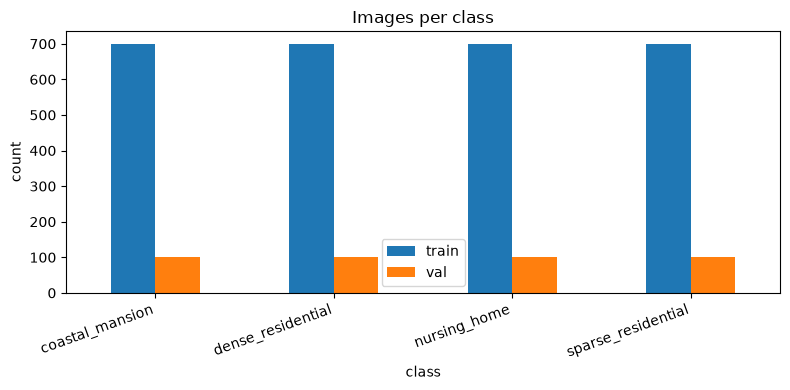

In [10]:
train_counts = count_split(config.TRAIN_DIR)
val_counts = count_split(config.VAL_DIR)

counts_df = pd.DataFrame({"train": train_counts, "val": val_counts}).loc[config.CLASS_NAMES]
counts_df["total"] = counts_df["train"] + counts_df["val"]
display(counts_df)
print("Train total:", int(counts_df["train"].sum()), "| Val total:", int(counts_df["val"].sum()))

ax = counts_df[["train", "val"]].plot(kind="bar", figsize=(8, 4))
ax.set_title("Images per class")
ax.set_ylabel("count")
ax.set_xlabel("class")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 2. Sample images per class

A first look at what each category actually contains.

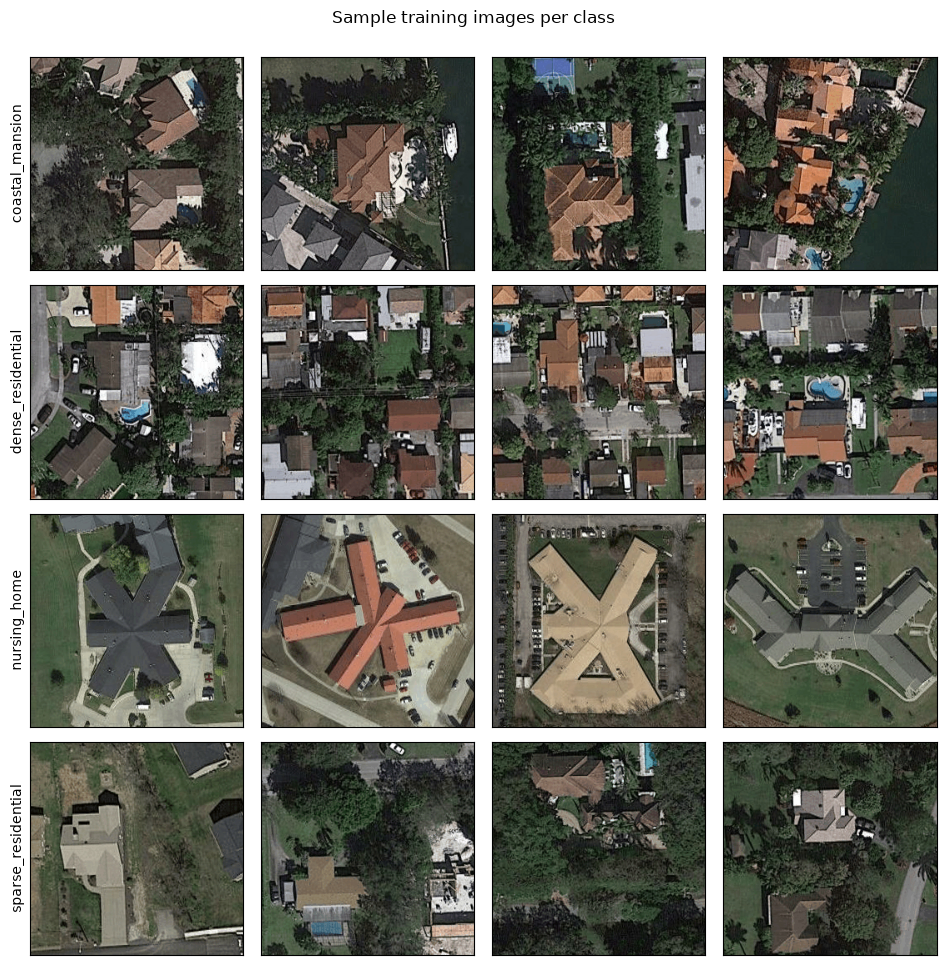

In [11]:
N_PER_CLASS = 4
fig, axes = plt.subplots(
    len(config.CLASS_NAMES), N_PER_CLASS,
    figsize=(N_PER_CLASS * 2.4, len(config.CLASS_NAMES) * 2.4),
)
for r, cls in enumerate(config.CLASS_NAMES):
    picks = random.sample(list_images(os.path.join(config.TRAIN_DIR, cls)), N_PER_CLASS)
    for c, p in enumerate(picks):
        ax = axes[r, c]
        ax.imshow(Image.open(p).convert("RGB"))
        ax.set_xticks([])
        ax.set_yticks([])
        if c == 0:
            ax.set_ylabel(cls, fontsize=10)
plt.suptitle("Sample training images per class", y=1.0)
plt.tight_layout()
plt.show()

## 3. The confusable classes, side by side

The core challenge of this partition is that the classes are *visually confusable*. Put one
representative of each class in a single row and judge how similar they look — this is the
intuition behind why a fine-grained model (and strong augmentation) is needed.

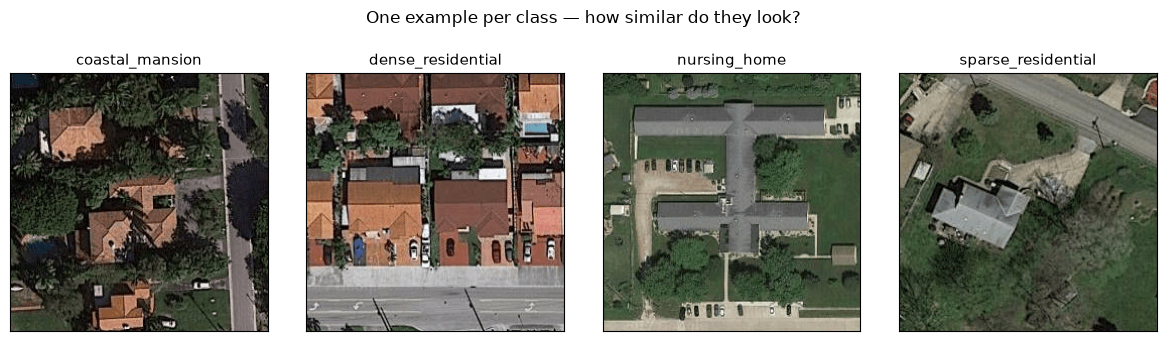

In [12]:
fig, axes = plt.subplots(1, len(config.CLASS_NAMES), figsize=(len(config.CLASS_NAMES) * 3, 3.2))
for ax, cls in zip(axes, config.CLASS_NAMES):
    p = random.choice(list_images(os.path.join(config.TRAIN_DIR, cls)))
    ax.imshow(Image.open(p).convert("RGB"))
    ax.set_title(cls, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("One example per class — how similar do they look?", y=1.05)
plt.tight_layout()
plt.show()

## 4. Image size, aspect ratio & colour stats

Sample images per class and inspect their dimensions and colour mode. This tells us whether
the fixed 224x224 resize in the shared loader distorts images (non-square aspect ratios) and
whether any images are greyscale / CMYK rather than RGB.

Sampled 400 images


width                                                 \
                    count   mean  std    min    25%    50%    75%    max   
class                                                                      
coastal_mansion     100.0  256.0  0.0  256.0  256.0  256.0  256.0  256.0   
dense_residential   100.0  256.0  0.0  256.0  256.0  256.0  256.0  256.0   
nursing_home        100.0  256.0  0.0  256.0  256.0  256.0  256.0  256.0   
sparse_residential  100.0  256.0  0.0  256.0  256.0  256.0  256.0  256.0   

                   height         ...               aspect                 \
                    count   mean  ...    75%    max  count mean  std  min   
class                             ...                                       
coastal_mansion     100.0  256.0  ...  256.0  256.0  100.0  1.0  0.0  1.0   
dense_residential   100.0  256.0  ...  256.0  256.0  100.0  1.0  0.0  1.0   
nursing_home        100.0  256.0  ...  256.0  256.0  100.0  1.0  0.0  1.0   
sparse_residential  100.0  256.0  ...  256.0  256.0  100.0  1.0  0.0  1.0   

                                        
                    25%  50%  75%  max  
class                                   
coastal_mansion     1.0  1.0  1.0  1.0  
dense_residential   1.0  1.0  1.0  1.0  
nursing_home        1.0  1.0  1.0  1.0  
sparse_residential  1.0  1.0  1.0  1.0  

[4 rows x 24 columns]


Image colour modes present: {'RGB': 400}


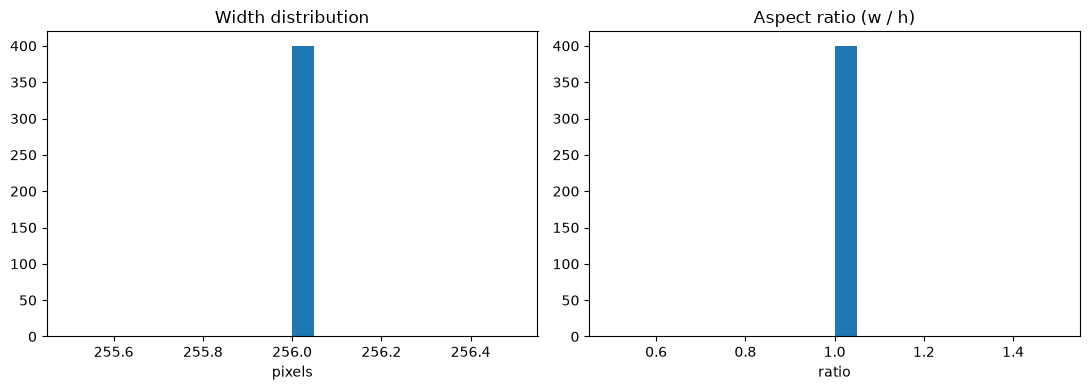

NOTE: the shared loader resizes everything to 224x224.


In [13]:
SAMPLE_PER_CLASS = 100
rows = []
for cls in config.CLASS_NAMES:
    paths = list_images(os.path.join(config.TRAIN_DIR, cls))
    for p in random.sample(paths, min(SAMPLE_PER_CLASS, len(paths))):
        with Image.open(p) as im:
            w, h = im.size
            mode = im.mode
        rows.append({"class": cls, "width": w, "height": h, "aspect": round(w / h, 3), "mode": mode})

stats_df = pd.DataFrame(rows)
print("Sampled", len(stats_df), "images")
display(stats_df.groupby("class")[["width", "height", "aspect"]].describe().round(2))
print("\nImage colour modes present:", stats_df["mode"].value_counts().to_dict())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(stats_df["width"], bins=20)
ax[0].set_title("Width distribution")
ax[0].set_xlabel("pixels")
ax[1].hist(stats_df["aspect"], bins=20)
ax[1].set_title("Aspect ratio (w / h)")
ax[1].set_xlabel("ratio")
plt.tight_layout()
plt.show()
print(f"NOTE: the shared loader resizes everything to {config.IMAGE_SIZE}x{config.IMAGE_SIZE}.")

## 5. Per-class colour signature

Aerial categories often differ in dominant colour (vegetation green, rooftops, water, sand).
Compare the mean RGB per class, and look at the *mean image* per class — averaging many images
reveals each class's typical colour/texture layout while washing out the specifics.

,R,G,B
coastal_mansion,74.2,71.6,63.0
dense_residential,89.7,86.3,77.3
nursing_home,96.9,100.6,88.0
sparse_residential,70.4,74.6,60.7


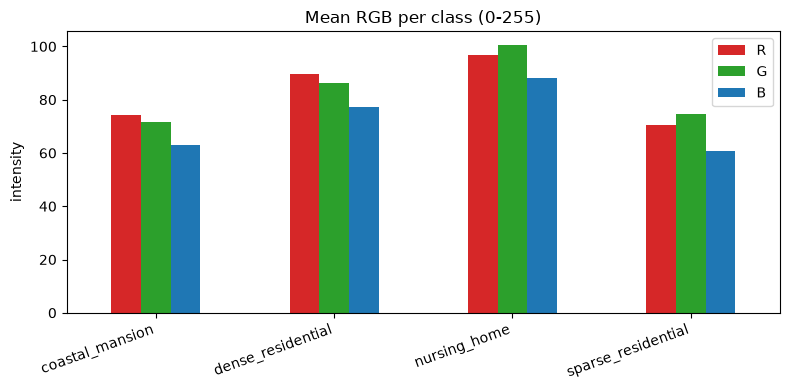

In [14]:
SAMPLE_PER_CLASS = 60
means = {}
mean_images = {}
for cls in config.CLASS_NAMES:
    paths = list_images(os.path.join(config.TRAIN_DIR, cls))
    sample = random.sample(paths, min(SAMPLE_PER_CLASS, len(paths)))
    acc = np.zeros((config.IMAGE_SIZE, config.IMAGE_SIZE, 3), dtype=np.float64)
    for p in sample:
        im = Image.open(p).convert("RGB").resize((config.IMAGE_SIZE, config.IMAGE_SIZE))
        acc += np.asarray(im, dtype=np.float64)
    acc /= len(sample)
    mean_images[cls] = acc
    means[cls] = acc.reshape(-1, 3).mean(axis=0)

means_df = pd.DataFrame(means, index=["R", "G", "B"]).T
display(means_df.round(1))

means_df.plot(kind="bar", color=["tab:red", "tab:green", "tab:blue"], figsize=(8, 4))
plt.title("Mean RGB per class (0-255)")
plt.ylabel("intensity")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

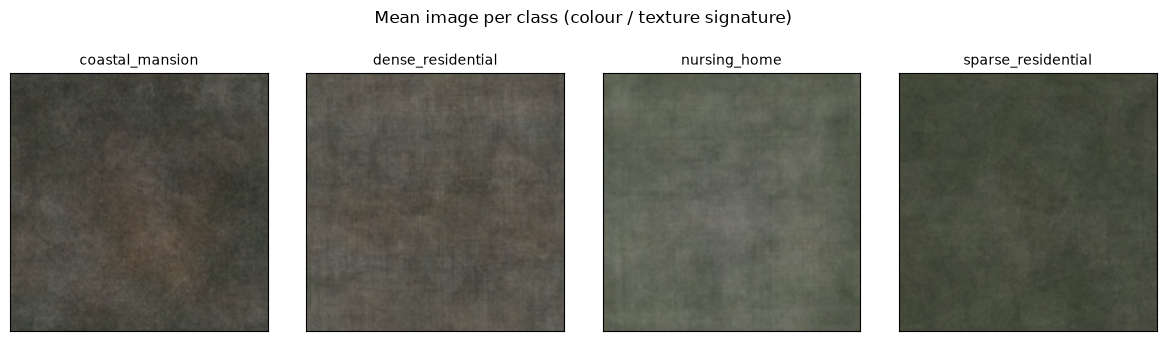

In [15]:
fig, axes = plt.subplots(1, len(config.CLASS_NAMES), figsize=(len(config.CLASS_NAMES) * 3, 3.2))
for ax, cls in zip(axes, config.CLASS_NAMES):
    ax.imshow(mean_images[cls].astype(np.uint8))
    ax.set_title(cls, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Mean image per class (colour / texture signature)", y=1.05)
plt.tight_layout()
plt.show()

## 6. Observations & implications for modelling

_Fill these in from what you see above — this becomes the EDA section of the report._

- **Class balance:** train/val counts are ___ (balanced as expected -> accuracy is a fair metric,
  no class weighting needed).
- **Visual confusability:** classes ___ and ___ look most alike (similar ___). Expect these to
  dominate the confusion matrix — watch their per-class F1 in `results/`.
- **Image size / aspect ratio:** images are ___ ; the 224x224 resize does / does not distort them.
- **Colour modes:** all images are RGB? (any greyscale/CMYK to flag).
- **Colour signature:** classes separate / do not separate well on mean colour alone — implies the
  model must rely on ___ (texture / structure), not just colour.
- **Augmentation justification:** flips + full rotations are valid because aerial scenes have no
  canonical "up" (confirmed by the samples above); mild brightness/contrast covers lighting
  variation without destroying fine-grained cues.

> Reminder: every observation here is derived from the **training** split (plus val *counts* only).
> No modelling decision is tuned on the validation images.